In [1]:
# load packages
import numpy as np 
import scipy.io
from scipy.io   import  loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt #import matplotlib as plt
from scipy.optimize import curve_fit 
import seaborn as sns #import mat73
import pickle as pkl
from datetime import datetime
from itertools import chain
from scipy.io import savemat

In [2]:
# set data directory and import files 
from pathlib import Path
MainDirData = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" / "Pipeline Processed Outputs" / "PrePostProcessed"
os.chdir(MainDirData) # change old dir, to this dir
d = os.listdir(MainDirData) # list files in dir
print(f'Files on hand: {d}')


# IMPORT SESSION DAY ORDER INDEX ARRAY
MainDir_Array = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" / "Pipeline Processed Outputs" / "SessionIndexKey"  
d_array = os.listdir(MainDir_Array)
print(f'Avilable Files to choose from: {len(d_array)}')
print(f'Files on hand: {d_array}')

# enter : 2 3 4

Files on hand: ['rca_clean_contrast_response_functions_data_study1_full_20250911_184409.mat']
Avilable Files to choose from: 2
Files on hand: ['Clean_RCA_SessionOrder_Index_full_20250917_173007.mat', 'Clean_RCA_SessionOrder_Index_full_20250922_123330.mat']


In [3]:
FileN = d[0]#d[1] # choose one        
FileN_Array= d_array[0]    
file_path1 = os.path.join(MainDirData, FileN) # join paths and prep 2 load
file_path2 = os.path.join(MainDir_Array, FileN_Array) # join paths and prep 2 load
print('Current WD:',file_path1) # does path exist ... ?
print('Does File #1 Exist?',os.path.exists(file_path1)) # yes or no
print('Does File #2 Exist?',os.path.exists(file_path2)) # yes or no

Current WD: /Users/patricia.naomi/Desktop/Visual_Plasticty_Pipeline/Pipeline Processed Outputs/PrePostProcessed/rca_clean_contrast_response_functions_data_study1_full_20250911_184409.mat
Does File #1 Exist? True
Does File #2 Exist? True


In [4]:
df = scipy.io.loadmat(file_path1) # RCA F1 File
print(df.keys())
studyList = scipy.io.loadmat(file_path2) # RCA F1 File
print(studyList.keys())

dict_keys(['__header__', '__version__', '__globals__', 'F1_RMS_Data', 'F2_RMS_Data', '2F1', '2F2', '4F1', '4F2', '6F1', '6F2', '8F1', '8F2', 'Files_pSubj', 'Attn_Condition_pFile', 'TotFiles_pSubj', 'Subject_ID_Tag'])
dict_keys(['__header__', '__version__', '__globals__', 'SessionDatesOrder', 'Clean_SessionDatesOrder', 'session_day_delay_groups'])


In [5]:
# f1_data = df['2F1']
# f2_data = df['2F2']

# f1_data = df['4F1']
# f2_data = df['4F2']

# f1_data = df['6F1']
# f2_data = df['6F2']

# f1_data = df['8F1']
# f2_data = df['8F2']

f1_data = df['F1_RMS_Data']
f2_data = df['F2_RMS_Data']

In [6]:
print(studyList['Clean_SessionDatesOrder'][0])
print(studyList['SessionDatesOrder'][0])

[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 2 1
 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 1 1 2 1 1 1 1 1 2 1 2 2 1]
[1. 2. 1. 2. 1. 2. 1. 2. 1. 2. 1. 2. 1. 2. 1. 2. 1. 0. 2. 1. 2. 1. 2. 1.
 2. 1. 2. 1. 2. 1. 2. 1. 1. 2. 1. 2. 2. 1. 1. 2. 1. 0. 2. 1. 1. 0. 2. 1.
 1. 2. 1. 2. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 2. 1. 1. 0. 1. 0. 1. 0. 1. 2.
 1. 2. 2. 1.]


In [7]:
t = studyList['Clean_SessionDatesOrder'][0]
print(t)
t = t.astype(int) # try Clean_SessionDatesOrder

x = df['Files_pSubj'][0]
x = x.astype(int)

y = df['Attn_Condition_pFile'][0]
y = y.astype(int)
z = df['TotFiles_pSubj'][0]
z = z.astype(int)
s = df['Subject_ID_Tag']
s = s.astype(int)


[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 2 1
 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 1 1 2 1 1 1 1 1 2 1 2 2 1]


In [8]:
print(t) # session order array
print(x) # subject files belonging to 1 person
print(y) # attention condition bool
print(z)
# print(z) # Day X per subect - this array lyk how many sessions 1 subj completed and what day it was - not needed for this analysis 
# NumFileCount = np.array(np.arange(0,int(len(x)),1))
NumSubj = int(len(np.unique(x)))
print(NumSubj)

[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 2 1
 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 1 1 2 1 1 1 1 1 2 1 2 2 1]
[ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  9  9 10 10 11 11 12
 12 13 13 14 14 15 15 16 16 17 17 18 18 19 19 20 21 21 22 23 23 24 24 25
 25 26 27 28 29 30 31 31 32 33 34 35 35 36 36 37 37]
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0
 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 2 1 2 1 2]
38


In [9]:
print((f1_data.shape))
[Files, timeBlocks, NumBins] = f1_data.shape
# print((f1_data))

(65, 2, 6)


In [10]:
offset_vals_hemis = [-0.025, 0.05,0.025, 0.05]

timeBlockLabels = ['pre', 'post'] 

hemiF_colors_F1 = ['black','#41c770']
hemiF_colors_F2 = ['black','#b555ff']

#### **Plot Average Response Across Hemfields**

In [15]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
# plt.suptitle('Average non-normalized RCA RMS Response Functions for Contrast Condition @ F1, F2')

# for tB in range(timeBlocks):
#     massMean_F1 = np.nanmean(f1_data[:, tB, :], axis=0)
#     axs[0].plot(massMean_F1, label=f'F1 timeBlock {tB+1}')
    
#     massMean_F2 = np.nanmean(f2_data[:, tB, :], axis=0)
#     axs[1].plot(massMean_F2, label=f'F2 timeBlock {tB+1}')

# axs[0].set_title('F1 Response')
# axs[1].set_title('F2 Response')
# axs[0].set_ylabel('RMS Response')
# axs[0].set_xlabel('Bin')
# axs[1].set_xlabel('Bin')

# axs[0].legend()
# axs[1].legend()
# plt.show()


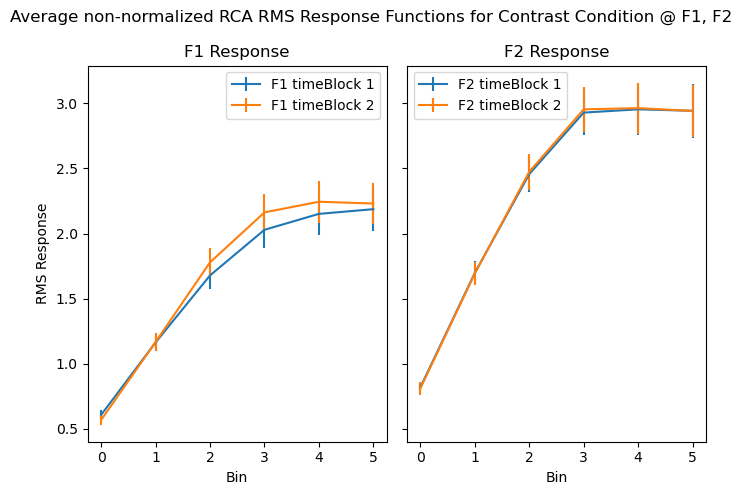

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)
plt.suptitle('Average non-normalized RCA RMS Response Functions for Contrast Condition @ F1, F2')

for tB in range(timeBlocks):
    f1_block = f1_data[:, tB, :]  # [numFreqs x numBins]
    f2_block = f2_data[:, tB, :]
    
    mean_f1 = np.nanmean(f1_block, axis=0)
    sem_f1 = np.nanstd(f1_block, axis=0) / np.sqrt(np.sum(~np.isnan(f1_block), axis=0))
    
    mean_f2 = np.nanmean(f2_block, axis=0)
    sem_f2 = np.nanstd(f2_block, axis=0) / np.sqrt(np.sum(~np.isnan(f2_block), axis=0))
    
    axs[0].errorbar(np.arange(NumBins), mean_f1, yerr=sem_f1, label=f'F1 timeBlock {tB+1}')
    axs[1].errorbar(np.arange(NumBins), mean_f2, yerr=sem_f2, label=f'F2 timeBlock {tB+1}')

axs[0].set_title('F1 Response')
axs[1].set_title('F2 Response')
axs[0].set_ylabel('RMS Response')
axs[0].set_xlabel('Bin')
axs[1].set_xlabel('Bin')

axs[0].legend()
axs[1].legend()
plt.tight_layout()
plt.show()


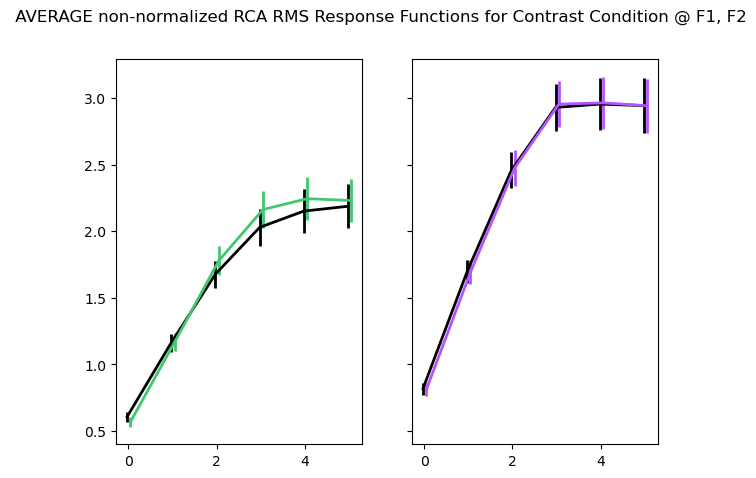

In [12]:
fig,axs = plt.subplots(1,2,figsize = ((7,5)), sharey = True)
plt.suptitle(f' AVERAGE non-normalized RCA RMS Response Functions for Contrast Condition @ F1, F2')

for tB in range(timeBlocks):

    #### LEFT HEMIFIELD DATA ###########################
    numObs_F1 = int(f1_data[:,tB,:].shape[0])
    massMean_F1 = np.nanmean(f1_data[:,tB,:],axis = 0) # subj  x timeBLock x Contrast values
    mass_Dev_F1 = ((np.nanstd(f1_data[:,tB,:],axis = 0)) / (np.sqrt(numObs_F1)))

    axs[0].errorbar(np.arange(0,NumBins,1)+offset_vals_hemis[tB], massMean_F1, yerr = mass_Dev_F1, linewidth = 2, color = hemiF_colors_F1[tB] )
    # axs[0].plot(massMean_F1, label = f'F1 timeBlock {tB+1}')


    #### RIGHT HEMIFIELD DATA ###########################
    numObs_F2 = int(f2_data[:,tB,:].shape[0])
    massMean_F2 = np.nanmean(f2_data[:,tB,:],axis = 0)
    mass_Dev_F2 = ((np.nanstd(f2_data[:,tB,:],axis = 0)) / (np.sqrt(numObs_F2)))

    # axs[1].plot(massMean_F2, label = f'F2 timeBlock {tB+1}')
    axs[1].errorbar(np.arange(0,NumBins,1)+offset_vals_hemis[tB], massMean_F2, yerr = mass_Dev_F2, linewidth = 2, color = hemiF_colors_F2[tB] )
    
# axs[0].legend()
# axs[1].legend()

In [14]:
NumSubs = ((int(np.max(x))))
print(f'A total of {NumSubs} subjs will be processed for analysis')

A total of 37 subjs will be processed for analysis


In [19]:
# # Plot crf data across days for all particpants

# for Subj in range(1): # NumSubs
#     DataSet_f1 = f1_data[x == Subj,:,:] # [Session Day Data x timeBlocks x NumBins]
#     DataSet_f2 = f2_data[x == Subj,:,:]

#     dataDims = DataSet_f1.shape

#     fig,axs = plt.subplots(1,2,figsize = ((9,4)), sharey = True)
#     plt.suptitle(f'non-normalized RCA RMS Response Functions for Contrast Condition on diff sessions| subj| {Subj+1}')

#     for NumSess in range(dataDims[0]):
#         axs[NumSess].plot(DataSet_f1[NumSess,0,:], label = 'F1 pre', color = 'black')
#         axs[NumSess].plot(DataSet_f1[NumSess,1,:], label = 'F1 post', color = 'blue')

#         axs[NumSess].plot(DataSet_f2[NumSess,0,:], label = 'F2 pre', color = 'brown')
#         axs[NumSess].plot(DataSet_f2[NumSess,1,:], label = 'F2 post', color = 'green')

#         axs[1].legend(loc = 'upper left')

#     plt.show()

## ****Perform  Normalization | Responses Anchored to Maximum Pre-Inducion Response****

In [15]:
print(x)

[ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  9  9 10 10 11 11 12
 12 13 13 14 14 15 15 16 16 17 17 18 18 19 19 20 21 21 22 23 23 24 24 25
 25 26 27 28 29 30 31 31 32 33 34 35 35 36 36 37 37]


In [21]:
# F1_Normalized = {}
# F2_Normalized = {}

# for Subj in range(NumSubs): #NumSubs
#     # files indicies per subject |  x == Subj

#     DataSet_f1 = f1_data[x == Subj,:,:] # [Session Day Data x timeBlocks x NumBins] 
#     DataSet_f2 = f2_data[x == Subj,:,:]

#     # print(DataSet_f1.shape)

#     dataDims = DataSet_f1.shape  # 2 x 2 x 6 [Sess x timeBlocks x NumBins]

#     if dataDims[0] != 2:
#         print(f'Single Session Detected, normalizing data... ')

#         mainNorm_F1 = DataSet_f1[0,0,:] # 1st session - pre vep responses, for all 6 bins
#         mainNormAnchor_F1 = np.max(mainNorm_F1)
#         Norm_Mat_F1 = DataSet_f1 / mainNormAnchor_F1
#         F1_Normalized[f'NormFile_{Subj}'] = Norm_Mat_F1

#         mainNorm_F2 = DataSet_f2[0,0,:]
#         mainNormAnchor_F2 = np.max(mainNorm_F2)
#         Norm_Mat_F2 = DataSet_f2 / mainNormAnchor_F2
#         F2_Normalized[f'NormFile_{Subj}'] = Norm_Mat_F2

#         # print(mainNormAnchor_F1,mainNormAnchor_F2)

#     else:

#         print(f'Normalizing 2 Session Datasets to Max Pre Day 1 Responses ... ')
#         fileLocs = t[Subj == x] 
#         print(fileLocs)
#         fileLocs_List = list(fileLocs)

#         firstSess = fileLocs_List.index(1) # find the location of where the first session data is found in the imported data array
#         print(firstSess)

#         mainNorm_F1 = DataSet_f1[firstSess,0,:] # 1st session - pre vep responses, for all 6 bins
#         mainNormAnchor_F1 = np.max(mainNorm_F1)
#         Norm_Mat_F1 = DataSet_f1 / mainNormAnchor_F1
#         F1_Normalized[f'NormFile_{Subj}'] = Norm_Mat_F1

#         mainNorm_F2 = DataSet_f2[firstSess,0,:]
#         mainNormAnchor_F2 = np.max(mainNorm_F2)
#         Norm_Mat_F2 = DataSet_f2 / mainNormAnchor_F2
#         F2_Normalized[f'NormFile_{Subj}'] = Norm_Mat_F2

#         # print(mainNormAnchor_F1,mainNormAnchor_F2)

In [16]:
F1_Normalized, F2_Normalized = {}, {}

for Subj in range(NumSubs):
    DataSet_f1 = f1_data[x == Subj, :, :]
    DataSet_f2 = f2_data[x == Subj, :, :]

    if DataSet_f1.shape[0] != 2:
        print(f'Single Session Detected, normalizing data...')
        anchor_idx = 0  # use first session
    else:
        print(f'Normalizing 2 Session Datasets to Max Pre Day 1 Responses...')
        fileLocs = list(t[Subj == x])
        anchor_idx = fileLocs.index(1)

    norm_anchor_f1 = np.max(DataSet_f1[anchor_idx, 0, :])
    norm_anchor_f2 = np.max(DataSet_f2[anchor_idx, 0, :])

    F1_Normalized[f'NormFile_{Subj}'] = DataSet_f1 / norm_anchor_f1
    F2_Normalized[f'NormFile_{Subj}'] = DataSet_f2 / norm_anchor_f2


Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Single Session Detected, normalizing data...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pre Day 1 Responses...
Normalizing 2 Session Datasets to Max Pr

In [17]:
norm_f1_Mat = np.concatenate(list(F1_Normalized.values()), axis=0)
norm_f2_Mat = np.concatenate(list(F2_Normalized.values()), axis=0)


print(norm_f1_Mat.shape)
print(norm_f2_Mat.shape)
# norm_f1_Mat = np.zeros((f1_data.shape))
# norm_f2_Mat = np.zeros((f1_data.shape))

# rowCounter = 0 # Start of row index
# for nS in range(NumSubs):
#     rowStart = rowCounter # row to store data [beginning of indexing]

#     dataImport1 = F1_Normalized[f'NormFile_{nS}'] # import datafiles 
#     dataImport2 = F2_Normalized[f'NormFile_{nS}'] # same as above 


#     rowLen = dataImport1.shape[0] # find number of rows in data 
#     rowCounter  = rowCounter + rowLen # row to store data [end of indexing]

#     norm_f1_Mat[rowStart:rowCounter,:,:] = dataImport1 # store data :)
#     norm_f2_Mat[rowStart:rowCounter,:,:] = dataImport2 # store data

(63, 2, 6)
(63, 2, 6)


In [24]:
# norm_f1_Mat = np.stack(list(F1_Normalized.values()), axis=0)
# norm_f2_Mat = np.stack(list(F2_Normalized.values()), axis=0)

In [18]:
def MakeNewFolder(folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f'Folder {folder_name} created')
    else:
        print(f'Folder {folder_name} already exists')

In [19]:
DataDirOut = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" / "Pipeline Processed Outputs"

os.chdir(DataDirOut)

folder_name = 'Clean_PreS1_RMS_Data'
MakeNewFolder(folder_name)

os.chdir(folder_name)

Folder Clean_PreS1_RMS_Data already exists


In [20]:
dataOut = {
    'F1_CleanData' : norm_f1_Mat,
    'F2_CleanData' : norm_f2_Mat,
    'Files_pSubj'  :x,# id for subject data [how many files belong to 1 subject]
    'Attn_Condition_pFile': y, # attentional deplyment per file 
    'TotFiles_pSubj':z, # all file in terms of session day per subject
    'SessionOrder' : t,
    'Subj_ID': s
}

In [21]:
# Generate timestamp
fdnt = datetime.now().strftime("%Y%m%d_%H%M%S")

# Define a clear, lowercase, underscore-separated base name
base_name = "rms_normalized_preS1_contrast_sweep"

# Compose final export filename
export_filename = f"{base_name}_{fdnt}.mat"

print(export_filename)


rms_normalized_preS1_contrast_sweep_20260408_125614.mat


In [22]:
# Export to .mat file
savemat(export_filename, dataOut)

print(f"Data has been exported to '{export_filename}'.")

Data has been exported to 'rms_normalized_preS1_contrast_sweep_20260408_125614.mat'.
